In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from coherence import calc_coherence_unweighted

In [2]:
# Create a 200x200 grid
shape = (200, 200)

# Simulate SAR amplitude (Rayleigh distributed-ish for natural terrain)
amp1 = np.random.rayleigh(scale=1.0, size=shape)
amp2 = np.random.rayleigh(scale=1.0, size=shape)

# Simulate SAR phase
# Background is totally random phase (0 coherence)
phase1 = np.random.uniform(-np.pi, np.pi, shape)
phase2 = np.random.uniform(-np.pi, np.pi, shape)

# Create a "stable" coherent feature in the center (e.g., a city or bare rock)
# We force the phase of image 2 to perfectly match image 1 in this square
phase2[50:150, 50:150] = phase1[50:150, 50:150]

# Construct the complex SLC arrays
slc1 = amp1 * np.exp(1j * phase1)
slc2 = amp2 * np.exp(1j * phase2)

print("Synthetic SLCs generated.")

Synthetic SLCs generated.


In [3]:
# Calculate using a 5x5 Boxcar (Uniform) filter
coh_uniform = calc_coherence_unweighted(slc1, slc2, filter_type='uniform', window_size=(5, 5))

# Calculate using a Gaussian filter (sigma=2 usually approximates a 5x5 window's spread)
coh_gaussian = calc_coherence_unweighted(slc1, slc2, filter_type='gaussian', sigma=2)

print("Coherence calculations complete.")

complex128 complex128
complex128 complex128
Coherence calculations complete.


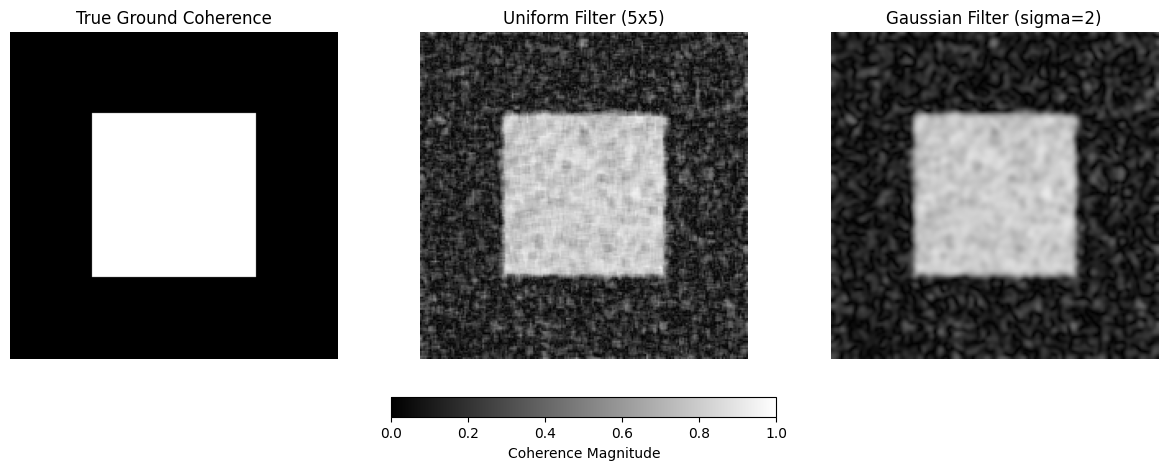

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# The actual ideal ground truth (1 in the middle, 0 on the outside)
true_coh = np.zeros(shape)
true_coh[50:150, 50:150] = 1.0

ax0 = axes[0].imshow(true_coh, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('True Ground Coherence')
axes[0].axis('off')

# Uniform Filter Output
ax1 = axes[1].imshow(coh_uniform, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Uniform Filter (5x5)')
axes[1].axis('off')

# Gaussian Filter Output
ax2 = axes[2].imshow(coh_gaussian, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Gaussian Filter (sigma=2)')
axes[2].axis('off')

plt.colorbar(ax2, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, label='Coherence Magnitude')
plt.show()

# Running on real data

In [5]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/uavsar_geoslcs/lowman/05208'
img1 = f'{data_dir}/lowman_05208_20002_006_200131_L090HH_01_BU_s1_2x8.slc.complex.tif'
img2 = f'{data_dir}/lowman_05208_20007_002_200213_L090HH_01_BU_s1_2x8.slc.complex.tif'

In [8]:
coh_gaus = calc_coherence_unweighted(img1, img2, filter_type='gaussian')
coh_uni = calc_coherence_unweighted(img1, img2, filter_type='uniform')

complex64 complex64
complex64 complex64


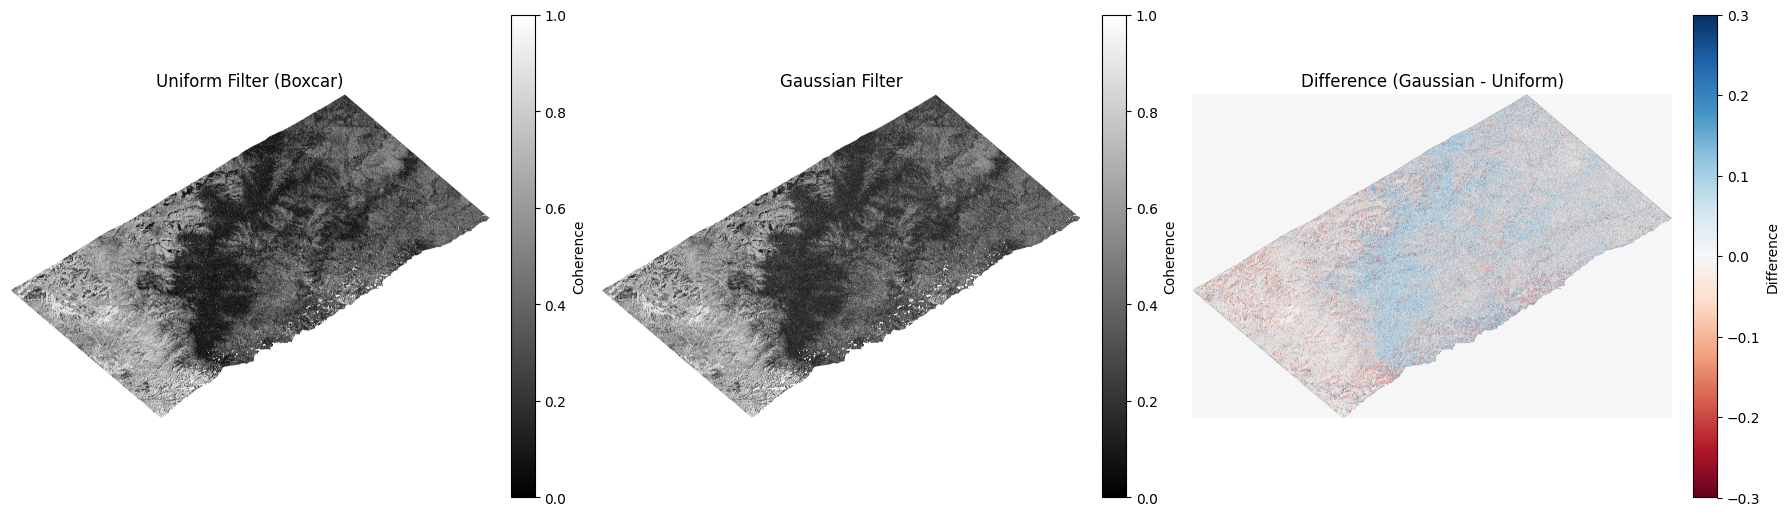

In [9]:
# Create a wide figure to fit three panels comfortably
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: Uniform Coherence ---
# Standard SAR coherence is almost always plotted in grayscale from 0 to 1
im0 = axes[0].imshow(coh_uni, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Uniform Filter (Boxcar)')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Coherence')

# --- Panel 2: Gaussian Coherence ---
im1 = axes[1].imshow(coh_gaus, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Gaussian Filter')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Coherence')

# --- Panel 3: Difference Map ---
# Gaussian minus Uniform
diff = coh_gaus - coh_uni

# Calculate a symmetric limit for the colorbar so white is exactly zero
# We clip it at 0.3 just in case there are wild outliers, keeping the colors punchy
v_limit = min(np.nanmax(np.abs(diff)), 0.3) 

# 'RdBu' (Red-White-Blue) is perfect here. 
# Red means Gaussian is higher, Blue means Uniform is higher, White means they match.
im2 = axes[2].imshow(diff, cmap='RdBu', vmin=-v_limit, vmax=v_limit)
axes[2].set_title('Difference (Gaussian - Uniform)')
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Difference')

plt.tight_layout()
plt.show()